# Stellar Luminosity — Regresión Lineal y Polinómica desde Cero

## 1. Establecer el ambiente

In [26]:
# Install required libraries (run this once if needed)
%pip install numpy pandas matplotlib

   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/10.0 MB 4.6 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/10.0 MB 8.2 MB/s eta 0:00:01
   ----------------------------- ---------- 7.3/10.0 MB 11.9 MB/s eta 0:00:01
   ---------------------------------------- 10.0/10.0 MB 12.5 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


In [12]:
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)

Python: 3.14.6 (main, Jul 23 2026, 14:44:54) [MSC v.1944 64 bit (AMD64)]
NumPy: 2.5.1
Matplotlib: 3.11.1


Load the dataset as NumPy arrays.

In [13]:
# Datos
mass = [0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4]
luminosity = [0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0]

# Convertir a arreglos de NumPy
mass = np.array(mass)
luminosity = np.array(luminosity)

Confirm the shapes and ranges of the variables.

In [14]:
# Formas (shapes)
print("Forma de mass:", mass.shape)
print("Forma de luminosity:", luminosity.shape)

# Rangos
print("Rango de mass:", mass.min(), "a", mass.max())
print("Rango de luminosity:", luminosity.min(), "a", luminosity.max())

Forma de mass: (10,)
Forma de luminosity: (10,)
Rango de mass: 0.6 a 2.4
Rango de luminosity: 0.15 a 35.0


## 2. Explorar antes de modelar

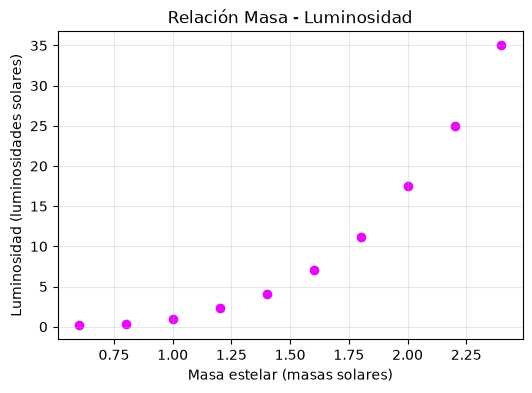

In [15]:
plt.figure(figsize=(6,4))
plt.scatter(mass, luminosity, color="#E808FC")
plt.xlabel("Masa estelar (masas solares)")
plt.ylabel("Luminosidad (luminosidades solares)")
plt.title("Relación Masa - Luminosidad")
plt.grid(True, alpha=0.3)
plt.show()

Describe the observed relationship.

la relación entre la masa estelar y la luminosidad es no lineal, para valores entre 0 y 1.50, son más cercanos, despues de este valor los valores suelen ser cada vez más separados, hasta llegar a 35 luminosidades para un valor entre 2.25 y 2.50.

Explain whether a straight line appears adequate and where systematic errors might occur.

Una linea no es adecuada, ya que no captura bien la curvatura, lo que se puede evidenciar es posiblemnete una polinomica.
Los errores se podrian producir en los extremos y se podrian producir valores no realistas en el contexto.

## 3. Implement the learning algorithm

We now implement the model and cost function using **NumPy arrays** and **vectorized operations**.

### 3.1 Hypothesis $f_{w,b}(x)$

For one house with four features, the model is:

$$
f_{w,b}(x) = w_1x_1 + w_2x_2 + w_3x_3 + w_4x_4 + b
$$

For all houses at once, the vectorized formula is:

$$
\hat{y} = Xw + b
$$

In NumPy, `X @ w` means matrix-vector multiplication.

In [16]:
def predict(X,w,b):
    return X @ w + b

### Cost Function $J(w,b)$ (Vectorized)

We recall
$$
J(w,b) = \frac{1}{2m} \sum_{i=1}^{m} \big( f_{w,b}(x^{(i)}) - y^{(i)} \big)^2.
$$

In vector form, if we define the error vector $e = \hat{y} - y$, then
$$
J(w,b) = \frac{1}{2m} e^T e.
$$


In [17]:
def compute_cost(X,y,w,b):
    m = X.shape[0]
    y_hat = predict(X,w,b)
    error = y_hat -y
    cost = (error @ error) /(2 * m)

    return cost 

## compute gradient

In [18]:
def compute_gradient(X,y,w,b):
    m = X.shape[0]
    y_hat = predict(X,w,b)
    error = y_hat -y

    dj_dw = (X.T @ error) / m
    dj_db = np.sum(error) / m

    return dj_dw, dj_db

## gradient_descent

In [19]:
def gradient_descent(X, y, w_init , b_init, alpha, num_iterations, print_progress = True):
    w = w_init.copy()
    b = b_init
    history_it = []
    history_cost = []

    for i in range(num_iterations):
        dj_dw, dj_db = compute_gradient(X,y,w,b)
        w -= alpha * dj_dw
        b -= alpha * dj_db

        cost = compute_cost(X,y,w,b)
        history_it.append(i)
        history_cost.append(cost)

        if print_progress and (i % max(1, num_iterations // 10) or i == num_iterations -1):
            print(f"Iteración {i:5d}: Costo {cost:10.4f}")

    return w, b, history_it, history_cost

## Train a linear model

In [ ]:
X_linear = mass.reshape(-1, 1)
print("X_linear shape:", X_linear.shape)

# inicializamos los parametros
w_init = np.zeros(1)
b_init = 0.0

#Elegimos la tasa de aprendizaje e iteraciones
learning_rate = 0.01
iterations = 10000

# Entrenar
w_lin, b_lin, it_lin, cost_lin = gradient_descent(X_linear, luminosity, w_init, b_init, learning_rate, iterations)

print("w final: ", w_lin)
print("b final: ", b_lin)
print("Costo final: ", cost_lin[-1])


Grafica costo en funcion de la iteracion

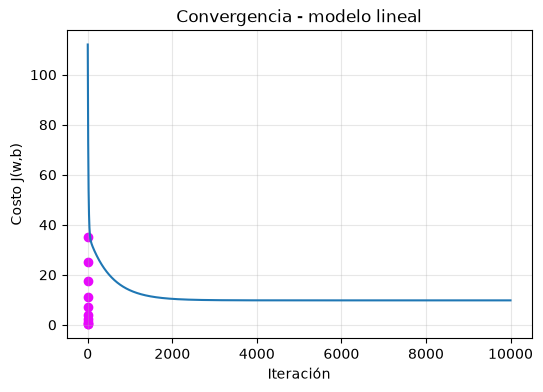

In [23]:
plt.figure(figsize = (6,4))
plt.scatter(mass, luminosity, color="#E808FC")
plt.plot(cost_lin)
plt.xlabel("Iteración")
plt.ylabel("Costo J(w,b)")
plt.title("Convergencia - modelo lineal")
plt.grid(True, alpha = 0.3)
plt.show()